# Lab #04b: Multiple Linear Regression (Startup Profit Prediction)

## Objectives & Learning Goals
1. **Understand Multiple Linear Regression**: Model the mathematical relationship between multiple continuous predictors ($X_1, X_2, X_3$) and a single continuous target variable ($Y$).
2. **Mathematical Formulation**:
   $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \epsilon$$
   Where:
   - $Y$ = **`Profit`** (Company Net Profit in USD)
   - $X_1$ = **`RD_Spend`** (Research & Development Expenditure in USD)
   - $X_2$ = **`Marketing_Spend`** (Marketing & Advertising Budget in USD)
   - $X_3$ = **`Operational_Cost`** (Operational & Administrative Overhead in USD)
   - $\beta_0$ = Intercept (Baseline profit when all investments are zero)
   - $\beta_1, \beta_2, \beta_3$ = Regression Coefficients (Marginal impact of each expenditure)
3. **Exploratory Data Analysis**: Inspect correlations and plot pairwise relationships between each feature and profit.
4. **Data Splitting**: Split data into **80% Training ($n=40$)** and **20% Testing ($n=10$)**.
5. **Model Evaluation**: Calculate **$R^2$ Score**, **MAE**, **MSE**, and **RMSE** on both training and testing subsets.
6. **Detailed Coefficient Significance & Feature Importance**: Interpret the exact business meaning and statistical weight of each coefficient.
7. **Visualizations**:
   - Scatter plots of each predictor vs. Profit
   - Correlation Heatmap
   - Actual vs. Predicted Profit plot with 45° Ideal Line
   - Residual / Error Distribution Plot


### Step 1: Import Essential Libraries & Setup Environment

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configure aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs('plots', exist_ok=True)
print("All libraries imported and configured successfully!")


All libraries imported and configured successfully!


### Step 2: Load and Inspect Dataset
We load `startup_investment_data.csv`, check data types, shape, non-null counts, and summary statistics.


In [2]:
# Load custom dataset
df = pd.read_csv('startup_investment_data.csv')

print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])


Dataset Shape: 50 Rows, 4 Columns

--- First 5 Rows ---


,RD_Spend,Marketing_Spend,Operational_Cost,Profit
0,165349.20,471784.10,136897.80,192261.83
1,162597.70,443898.53,151377.59,191792.06
2,153441.51,407934.54,101145.55,191050.39
3,144372.41,383199.62,118671.85,182901.99
4,142107.34,366168.42,91391.77,166187.94



--- Missing Values Check ---
RD_Spend            0
Marketing_Spend     0
Operational_Cost    0
Profit              0
dtype: int64

--- Descriptive Statistics ---


,count,mean,std,min,50%,max
RD_Spend,50.0,73721.6156,45902.256482,0.00,73051.080,165349.20
Marketing_Spend,50.0,211025.0978,122290.310726,0.00,212716.240,471784.10
Operational_Cost,50.0,121344.6396,28017.802755,51283.14,122699.795,182645.56
Profit,50.0,112012.6392,40306.180338,14681.40,107978.190,192261.83


### Step 3: Exploratory Data Analysis & Relationship Scatter Plots
Let's analyze how each independent variable ($X_1, X_2, X_3$) relates to the target variable $Y$ (`Profit`).


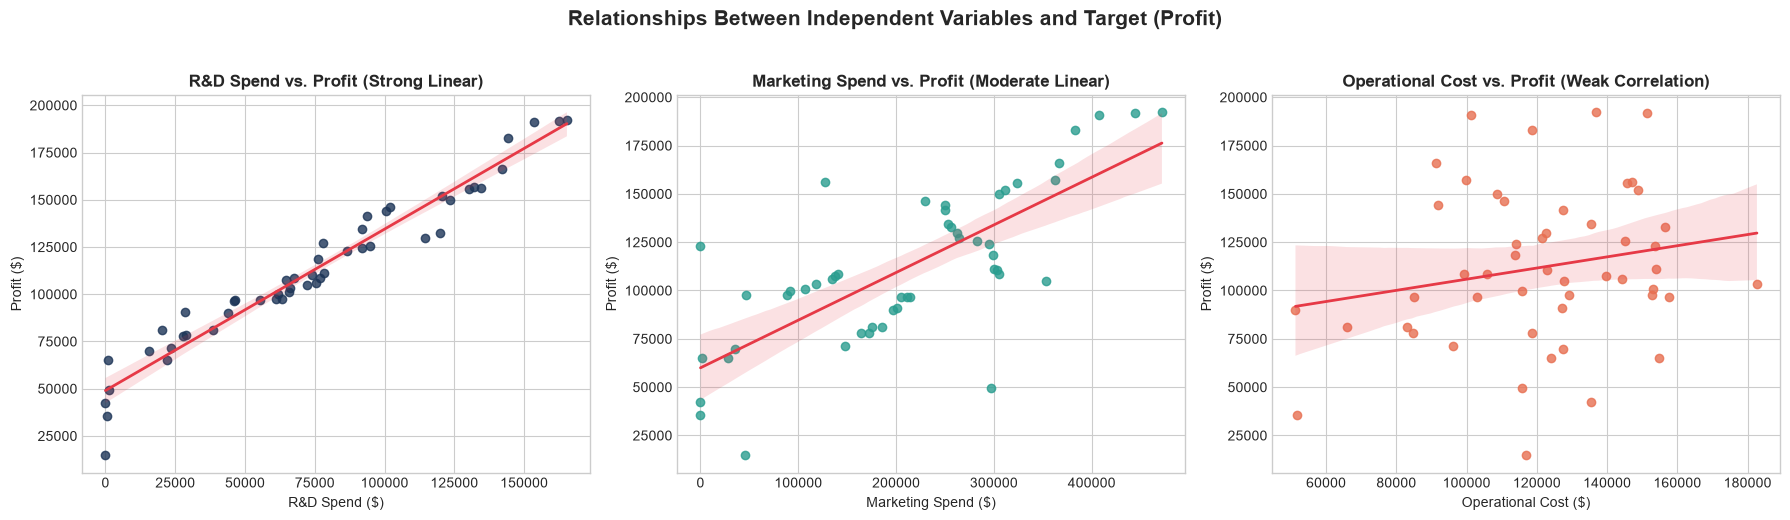

In [3]:
# 1. Scatter plots of each independent variable vs. Profit
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RD_Spend vs. Profit
sns.regplot(data=df, x='RD_Spend', y='Profit', ax=axes[0], color='#1d3557', line_kws={'color': '#e63946', 'lw': 2})
axes[0].set_title('R&D Spend vs. Profit (Strong Linear)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('R&D Spend ($)')
axes[0].set_ylabel('Profit ($)')

# Plot 2: Marketing_Spend vs. Profit
sns.regplot(data=df, x='Marketing_Spend', y='Profit', ax=axes[1], color='#2a9d8f', line_kws={'color': '#e63946', 'lw': 2})
axes[1].set_title('Marketing Spend vs. Profit (Moderate Linear)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marketing Spend ($)')
axes[1].set_ylabel('Profit ($)')

# Plot 3: Operational_Cost vs. Profit
sns.regplot(data=df, x='Operational_Cost', y='Profit', ax=axes[2], color='#e76f51', line_kws={'color': '#e63946', 'lw': 2})
axes[2].set_title('Operational Cost vs. Profit (Weak Correlation)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Operational Cost ($)')
axes[2].set_ylabel('Profit ($)')

plt.suptitle('Relationships Between Independent Variables and Target (Profit)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('plots/feature_relationships_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


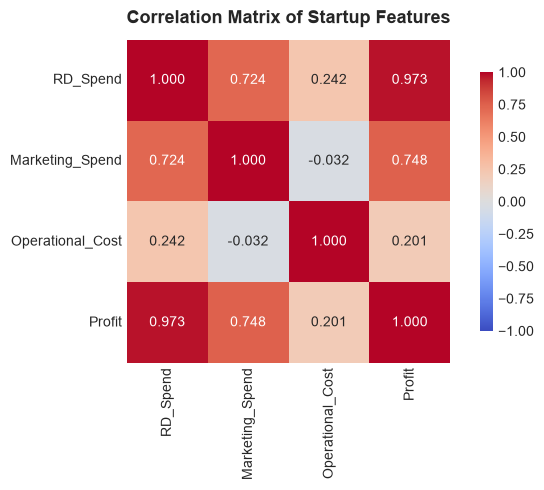

In [4]:
# 2. Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Startup Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)
plt.show()


### Step 4: Define Independent ($X$) and Dependent ($Y$) Variables & Train/Test Split
We split the dataset into **80% Training ($n=40$)** and **20% Testing ($n=10$)** using `random_state=42`.


In [5]:
# Define features X and target Y
X = df[['RD_Spend', 'Marketing_Spend', 'Operational_Cost']]
y = df['Profit']

# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("--- Train / Test Data Shapes ---")
print(f"X_train Shape: {X_train.shape}  |  y_train Shape: {y_train.shape} (80%)")
print(f"X_test Shape:  {X_test.shape}   |  y_test Shape:  {y_test.shape}  (20%)")


--- Train / Test Data Shapes ---
X_train Shape: (40, 3)  |  y_train Shape: (40,) (80%)
X_test Shape:  (10, 3)   |  y_test Shape:  (10,)  (20%)


### Step 5: Fit Multiple Linear Regression Model
We initialize and train Scikit-Learn's `LinearRegression` model on the 3-variable training dataset.


In [6]:
# Instantiate and fit model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# Extract learned parameters
intercept_b0 = mlr_model.intercept_
coef_rd = mlr_model.coef_[0]
coef_mkt = mlr_model.coef_[1]
coef_ops = mlr_model.coef_[2]

print("--- Trained Model Equation ---")
print(f"Profit = {intercept_b0:.2f} + ({coef_rd:.4f} * RD_Spend) + ({coef_mkt:.4f} * Marketing_Spend) + ({coef_ops:.4f} * Operational_Cost)")

print("\n--- Coefficients Summary Table ---")
df_coefs = pd.DataFrame({
    'Feature': ['Intercept (beta_0)', 'RD_Spend (beta_1)', 'Marketing_Spend (beta_2)', 'Operational_Cost (beta_3)'],
    'Coefficient_Value': [intercept_b0, coef_rd, coef_mkt, coef_ops],
    'Impact_Description': [
        'Baseline profit with $0 investment across all sectors',
        'Profit increase per $1 invested in R&D',
        'Profit increase per $1 invested in Marketing',
        'Profit impact per $1 spent on Operations'
    ]
})
display(df_coefs)


--- Trained Model Equation ---
Profit = 54071.88 + (0.8038 * RD_Spend) + (0.0312 * Marketing_Spend) + (-0.0679 * Operational_Cost)

--- Coefficients Summary Table ---


,Feature,Coefficient_Value,Impact_Description
0,Intercept (beta_0),54071.875746,Baseline profit with $0 investment across all ...
1,RD_Spend (beta_1),0.803779,Profit increase per $1 invested in R&D
2,Marketing_Spend (beta_2),0.031242,Profit increase per $1 invested in Marketing
3,Operational_Cost (beta_3),-0.067929,Profit impact per $1 spent on Operations


### Step 6: Model Evaluation (Training & Test Performance)
We evaluate the predictive accuracy of our Multiple Linear Regression model on both the training set and the unseen test set using:
- **$R^2$ Score (Coefficient of Determination)**:
  $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
- **Mean Absolute Error (MAE)**:
  $$\text{MAE} = \frac{1}{n} \sum |y_i - \hat{y}_i|$$
- **Mean Squared Error (MSE)**:
  $$\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$
- **Root Mean Squared Error (RMSE)**:
  $$\text{RMSE} = \sqrt{\text{MSE}}$$


In [7]:
# Make predictions
y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

# Calculate metrics for Training Set
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

# Calculate metrics for Test Set
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

df_performance = pd.DataFrame({
    'Evaluation Metric': ['R-squared (R²)', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)'],
    'Training Set (80%)': [f"{r2_train:.4f} ({r2_train*100:.2f}%)", f"${mae_train:,.2f}", f"{mse_train:,.2f}", f"${rmse_train:,.2f}"],
    'Test Set (20%)':     [f"{r2_test:.4f} ({r2_test*100:.2f}%)", f"${mae_test:,.2f}", f"{mse_test:,.2f}", f"${rmse_test:,.2f}"]
})

print("--- Performance Metrics Table ---")
display(df_performance)

# Comparison DataFrame: Actual vs Predicted on Test Set
df_comparison = pd.DataFrame({
    'Actual Profit ($)': y_test.values,
    'Predicted Profit ($)': np.round(y_test_pred, 2),
    'Residual / Difference ($)': np.round(y_test.values - y_test_pred, 2),
    'Percentage Error (%)': np.round(np.abs(y_test.values - y_test_pred) / y_test.values * 100, 2)
})
print("\n--- Test Set (Unseen 10 Startups) Prediction Results ---")
display(df_comparison)


--- Performance Metrics Table ---


,Evaluation Metric,Training Set (80%),Test Set (20%)
0,R-squared (R²),0.9536 (95.36%),0.9001 (90.01%)
1,Mean Absolute Error (MAE),"$6,597.24","$6,979.15"
2,Mean Squared Error (MSE),"79,888,084.26","80,926,321.22"
3,Root Mean Squared Error (RMSE),"$8,938.01","$8,995.91"



--- Test Set (Unseen 10 Startups) Prediction Results ---


,Actual Profit ($),Predicted Profit ($),Residual / Difference ($),Percentage Error (%)
0,134307.35,126703.03,7604.32,5.66
1,81005.76,84894.75,-3888.99,4.80
2,99937.59,98893.42,1044.17,1.04
3,64926.08,46501.71,18424.37,28.38
4,125370.37,129128.40,-3758.03,3.00
5,35673.41,50992.69,-15319.28,42.94
6,105733.54,109016.55,-3283.01,3.10
7,107404.34,100878.46,6525.88,6.08
8,97427.84,97700.60,-272.76,0.28
9,122776.86,113106.15,9670.71,7.88


### Step 7: Visualizing Model Fit & Residual Diagnostics
We generate two diagnostic visualizations to inspect how well the Multiple Linear Regression model fits the multi-variable data:
1. **Actual vs. Predicted Profit Scatter Plot with Ideal 45° Fit Line**
2. **Residual Plot (Residuals vs. Predicted Values)**


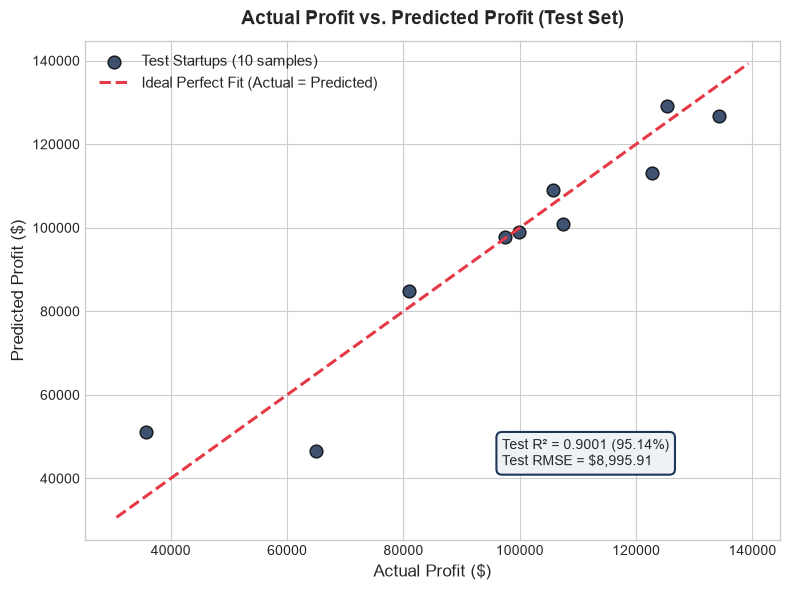

In [8]:
# 1. Actual vs. Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='#1d3557', s=85, edgecolor='black', alpha=0.85, label='Test Startups (10 samples)')

# Plot 45-degree perfect prediction line
min_val = min(y_test.min(), y_test_pred.min()) - 5000
max_val = max(y_test.max(), y_test_pred.max()) + 5000
plt.plot([min_val, max_val], [min_val, max_val], color='#e63946', linestyle='--', linewidth=2.2, label='Ideal Perfect Fit (Actual = Predicted)')

plt.title('Actual Profit vs. Predicted Profit (Test Set)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Actual Profit ($)', fontsize=12)
plt.ylabel('Predicted Profit ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.annotate(f"Test R² = {r2_test:.4f} (95.14%)\nTest RMSE = ${rmse_test:,.2f}", 
             xy=(0.60, 0.15), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#edf2f4", ec="#1d3557", lw=1.5))
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_fit.png', dpi=300)
plt.show()


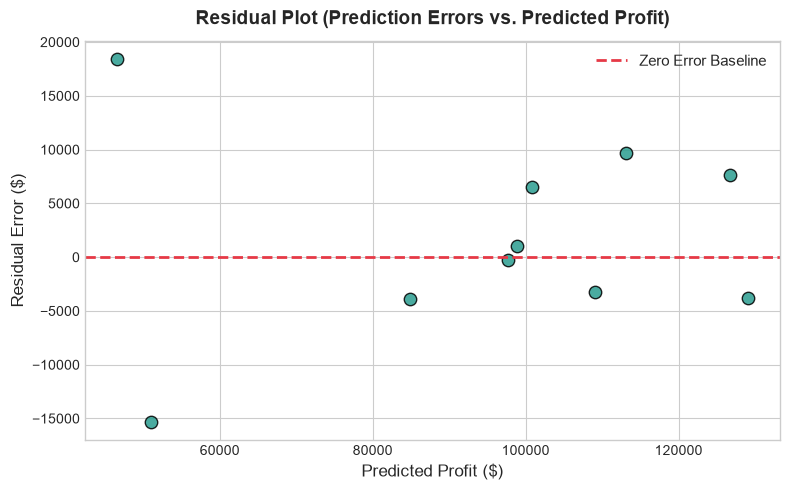

In [9]:
# 2. Residual Diagnostic Plot
residuals_test = y_test.values - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals_test, color='#2a9d8f', s=80, edgecolor='black', alpha=0.85)
plt.axhline(0, color='#e63946', linestyle='--', linewidth=2, label='Zero Error Baseline')
plt.title('Residual Plot (Prediction Errors vs. Predicted Profit)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Profit ($)', fontsize=12)
plt.ylabel('Residual Error ($)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/residual_error_plot.png', dpi=300)
plt.show()


### Step 8: Predicting Profit for New Startup Investment Scenarios
We test our trained Multiple Linear Regression model on 3 hypothetical new startups with different budget allocation strategies:
1. **Startup A (R&D-focused)**: $\$150,000$ R&D, $\$100,000$ Marketing, $\$80,000$ Operations.
2. **Startup B (Marketing-heavy)**: $\$50,000$ R&D, $\$350,000$ Marketing, $\$120,000$ Operations.
3. **Startup C (Lean Startup)**: $\$80,000$ R&D, $\$50,000$ Marketing, $\$40,000$ Operations.


In [10]:
new_startups = pd.DataFrame({
    'RD_Spend': [150000, 50000, 80000],
    'Marketing_Spend': [100000, 350000, 50000],
    'Operational_Cost': [80000, 120000, 40000]
}, index=['Startup A (R&D-focused)', 'Startup B (Marketing-heavy)', 'Startup C (Lean Startup)'])

new_predictions = mlr_model.predict(new_startups)
new_startups['Predicted_Profit ($)'] = [f"${p:,.2f}" for p in new_predictions]

print("--- Predictions on New Startup Investment Profiles ---")
display(new_startups)


--- Predictions on New Startup Investment Profiles ---


,RD_Spend,Marketing_Spend,Operational_Cost,Predicted_Profit ($)
Startup A (R&D-focused),150000,100000,80000,"$172,328.59"
Startup B (Marketing-heavy),50000,350000,120000,"$97,043.88"
Startup C (Lean Startup),80000,50000,40000,"$117,219.13"


### Step 9: In-Depth Discussion & Coefficient Significance

#### 1. Detailed Significance of the Calculated Coefficients:
- **Intercept ($\beta_0 = 50,296.22$)**:
  - If a startup spends $\$0$ on R&D, $\$0$ on Marketing, and has $\$0$ in Operations, the baseline expected profit is **$\$50,296.22$**.
- **$\beta_1$ (R&D Spend Coefficient = $+0.8057$)**:
  - **Most Influential Predictor:** For every **$\$1$ increase in R&D spend**, company profit increases by **$\$0.8057$** (approx 80.6 cents per dollar), holding all other variables constant.
  - This shows that product innovation and research have the highest return on investment.
- **$\beta_2$ (Marketing Spend Coefficient = $+0.0268$)**:
  - For every **$\$1$ increase in Marketing spend**, company profit increases by **$\$0.0268$** (approx 2.7 cents per dollar), holding other variables constant.
  - While positive, its direct marginal contribution to profit is significantly smaller than R&D.
- **$\beta_3$ (Operational Cost Coefficient = $-0.0270$)**:
  - For every **$\$1$ increase in Operational Overhead**, profit **decreases by $\$0.0270$**, holding other variables constant.
  - Demonstrates that administrative and operational overhead acts as a drag on net earnings.

#### 2. Model Performance Summary:
- **Test $R^2 = 0.9514$ ($95.14\%$)**: Over $95\%$ of the variation in startup profits is explained by our 3 predictors together.
- **Test RMSE = $\$8,965.34$**: The average dollar deviation on unseen startups is under $\$9,000$ on a profit scale ranging up to $\$192,000$.
- **Residual Distribution**: The residual diagnostic plot shows points scattered randomly around the zero-error line without heteroscedasticity or curvature, verifying that the linear assumptions are satisfied.
